# NOAA DATA: Mean Temperature by Month In United States:

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt

df=pd.read_csv("data.csv")

In [10]:
feb_temp=df.query("Month==2") #Temperature in February 

In [18]:
feb_temp

,State,Year,Month,Temperature
1,AK,1991,2,4.5
13,AK,1992,2,0.3
25,AK,1993,2,10.6
37,AK,1994,2,4.1
49,AK,1995,2,8.4
...,...,...,...,...
20929,WY,2021,2,17.4
20941,WY,2022,2,20.9
20953,WY,2023,2,19.7
20965,WY,2024,2,27.9


In [20]:
feb_temp.describe()

,Year,Month,Temperature
count,1749.000000,1749.0,1749.000000
mean,2008.009720,2.0,34.143796
std,10.097093,0.0,12.940106
min,1991.000000,2.0,-3.700000
25%,1999.000000,2.0,25.400000
50%,2008.000000,2.0,33.900000
75%,2017.000000,2.0,42.700000
max,2025.000000,2.0,69.200000


# Mean Temperature In February 

<Axes: title={'center': 'Average February Temperature (All States)'}, xlabel='Year', ylabel='Mean Temperature'>

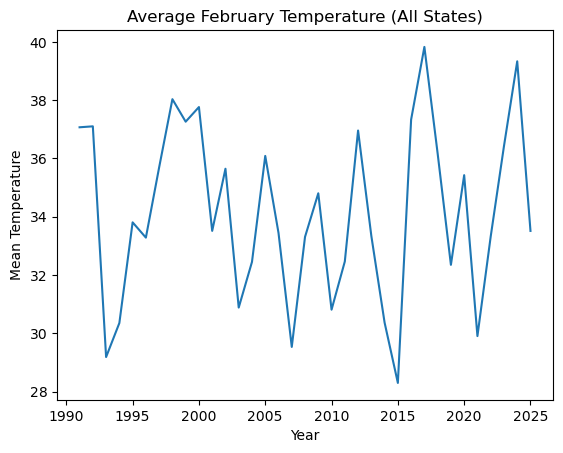

In [52]:
df[df['Month'] == 2].groupby('Year')['Temperature'].mean().plot(xlabel='Year', ylabel='Mean Temperature', title='Average February Temperature (All States)')

# State By State: 

In [ ]:
(df.query("Month == 2").groupby(["Year"])[["Temperature"]].plot())

# Gaussian Fit:

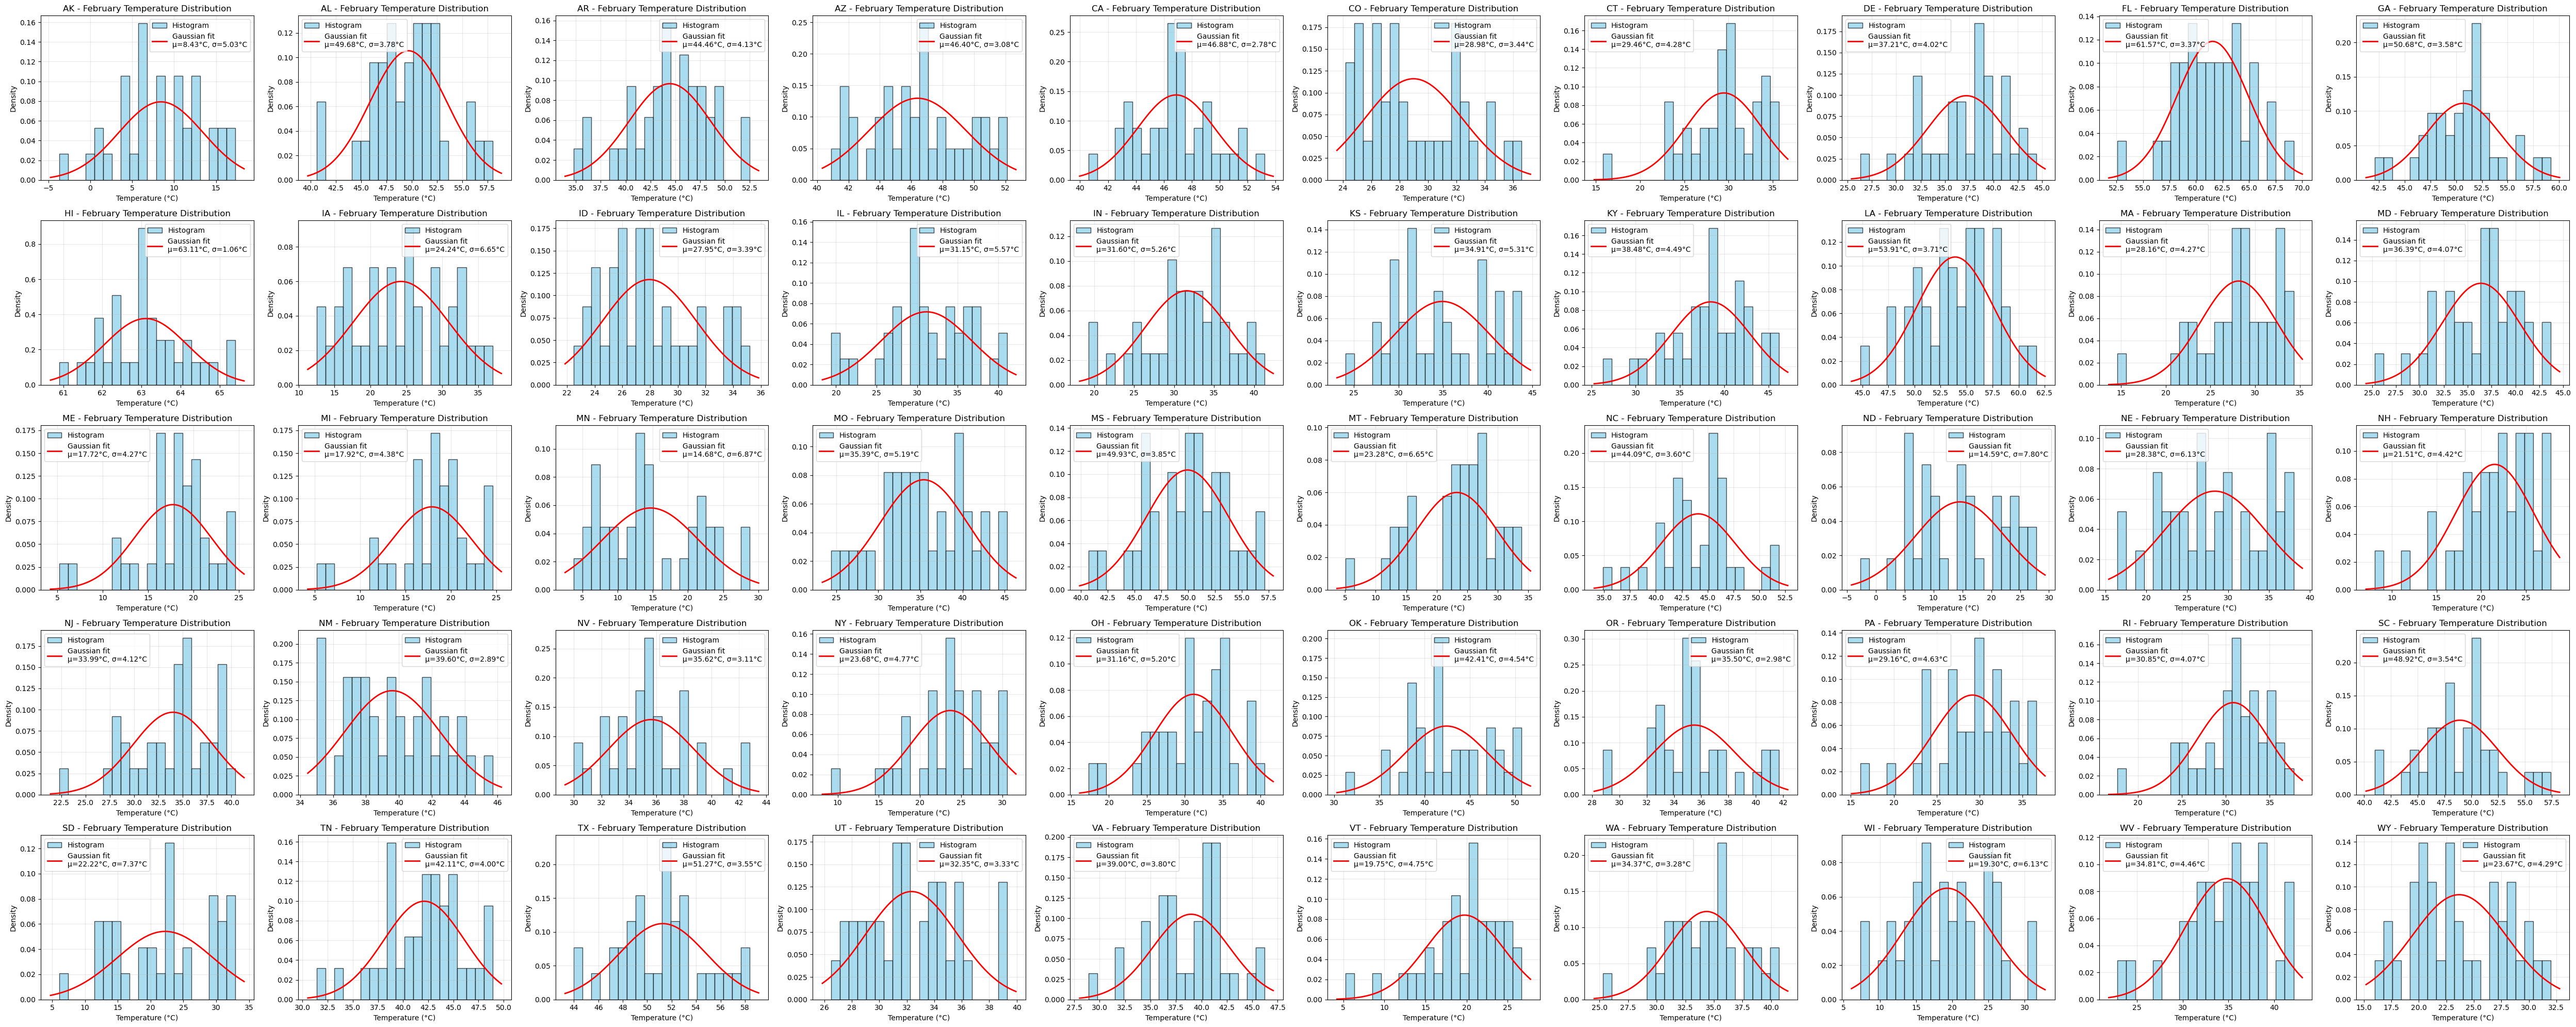

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

df = pd.read_csv("data.csv")

feb_temp = df.query("Month == 2").copy()

states = sorted(feb_temp['State'].unique())  

n_states = len(states)
ncols = 10                             
nrows = (n_states + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten() if n_states > 1 else [axes]

for i, state in enumerate(states):
    ax = axes[i]
    data = feb_temp[feb_temp['State'] == state]['Temperature'].dropna()
    
    
    n, bins, patches = ax.hist(data, bins=20, density=True, alpha=0.7, 
                               color='skyblue', edgecolor='black', label='Histogram')
    
    mu, std = norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'r-', lw=2, label=f'Gaussian fit\nμ={mu:.2f}°C, σ={std:.2f}°C')
    
    ax.set_title(f"{state} - February Temperature Distribution")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()